# 02. Làm sạch và tiền xử lý dữ liệu

Notebook này tương ứng **Bước 2: Làm sạch dữ liệu**.

Các kỹ thuật dùng trong bước này:
- `pd.to_numeric` để xử lý `TotalCharges`.
- `LabelEncoder` để encode categorical features.
- `train_test_split` để chia train/test.
- `SMOTENC` để cân bằng lớp churn trong train set.
- `StandardScaler` để scale các cột số.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

DEFAULT_ROOT = Path(r"C:\vscode\hoctap\Customer-Churn-Analysis")

def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents, DEFAULT_ROOT]:
        if (candidate / 'src').exists() and (candidate / 'configs').exists():
            return candidate
    raise FileNotFoundError('Khong tim thay project root.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import load_dataset
from src.data.preprocess import clean_dataframe, encode_dataframe, preprocess_pipeline
from src.utils.config import load_project_config

config = load_project_config(PROJECT_ROOT / 'configs' / 'config.yaml')
df_raw = load_dataset(PROJECT_ROOT / config['paths']['raw_data'])
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Kiểm tra vấn đề `TotalCharges`

`TotalCharges` có một số giá trị khoảng trắng nên cần chuyển sang dạng số.

In [2]:
blank_mask = df_raw['TotalCharges'].astype(str).str.strip() == ''
print('Blank TotalCharges rows:', blank_mask.sum())
df_raw.loc[blank_mask, ['tenure', 'MonthlyCharges', 'TotalCharges']].head()

Blank TotalCharges rows: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,


## 2. Làm sạch dữ liệu

Hàm `clean_dataframe` xử lý text, `TotalCharges`, missing values và bỏ `customerID`.

In [3]:
df_clean = clean_dataframe(df_raw)
print('Raw shape:', df_raw.shape)
print('Clean shape:', df_clean.shape)
print('customerID removed:', 'customerID' not in df_clean.columns)
print('Missing after clean:', df_clean.isna().sum().sum())
df_clean.head()

Raw shape: (7043, 21)
Clean shape: (7043, 20)
customerID removed: True
Missing after clean: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Encode dữ liệu phân loại

`LabelEncoder` chuyển dữ liệu chữ sang số để model học được.

In [4]:
encoded_df, encoders, numeric_columns, categorical_columns = encode_dataframe(df_clean, target_column='Churn')
print('Numeric columns:', numeric_columns)
print('Categorical columns:', categorical_columns)
encoded_df.head()

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## 4. Chạy pipeline tiền xử lý hoàn chỉnh

`preprocess_pipeline` gom các bước: clean, encode, split, SMOTENC và scale.

In [5]:
bundle = preprocess_pipeline(df_raw, config)
print('X_train:', bundle.X_train.shape)
print('X_test:', bundle.X_test.shape)
print('y_train:', bundle.y_train.shape)
print('y_test:', bundle.y_test.shape)
bundle.X_train.head()

X_train: (8278, 19)
X_test: (1409, 19)
y_train: (8278,)
y_test: (1409,)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,-0.406521,0,0,0.291580,0,1,0,0,0,2,0,2,2,0,0,2,-0.662137,-0.175148
1,1,-0.406521,1,1,-0.541721,1,0,1,2,0,0,0,0,0,0,0,3,0.237689,-0.424966
2,1,-0.406521,1,1,-0.625051,0,1,0,2,2,0,2,0,0,2,0,3,-0.962659,-0.679825
3,0,-0.406521,1,0,-0.083406,1,0,0,0,2,2,0,2,2,2,1,1,0.182101,-0.082482
4,1,-0.406521,1,1,-1.125031,1,0,0,0,0,0,0,0,0,0,0,2,-0.823689,-0.927690


## 5. Trước và sau SMOTENC

`SMOTENC` giúp cân bằng lớp trong tập train.

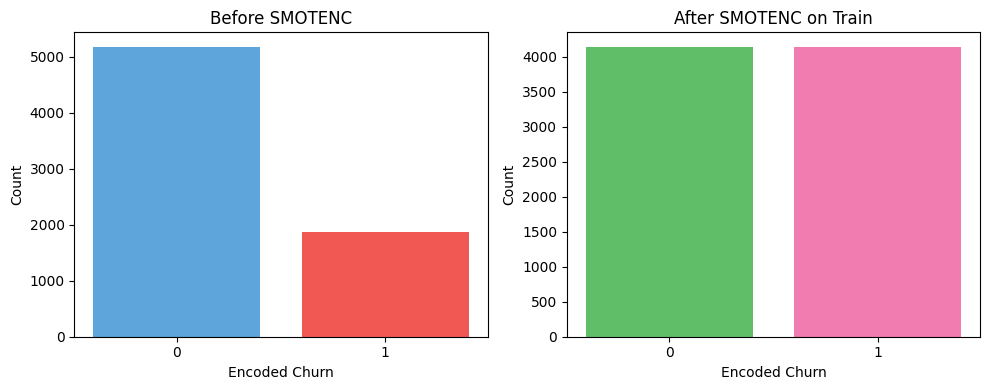

,before_all_data,after_train_smote
Churn,,
0,5174,4139
1,1869,4139


In [6]:
before_counts = encoded_df['Churn'].value_counts().sort_index()
after_counts = bundle.y_train.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(before_counts.index.astype(str), before_counts.values, color=['#5DA5DA', '#F15854'])
axes[0].set_title('Before SMOTENC')
axes[0].set_xlabel('Encoded Churn')
axes[0].set_ylabel('Count')
axes[1].bar(after_counts.index.astype(str), after_counts.values, color=['#60BD68', '#F17CB0'])
axes[1].set_title('After SMOTENC on Train')
axes[1].set_xlabel('Encoded Churn')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

pd.DataFrame({'before_all_data': before_counts, 'after_train_smote': after_counts})

## Kết luận bước 2

- Dữ liệu đã được làm sạch và encode.
- Train set đã được cân bằng bằng `SMOTENC`.
- Các cột số đã được scale bằng `StandardScaler`.